In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch import autograd as Grad

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.tri as mtri
import matplotlib

#import plotly.graph_objects as go

import ipywidgets as widgets
from IPython.display import display
import trimesh

import random
import math

import time
import os
import json

import copy
from implicit_reps import *

import open3d as o3d
print(o3d.__path__)
print('Using open3d version',o3d.__version__)
# Suppress Open3D warnings
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)

# Set device priority: MPS > CUDA > CPU

if torch.backends.mps.is_available():
    print("✅ MPS is available!")
else:
    print("❌ MPS is not available.")

    
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
✅ MPS is available!


In [2]:

from bns_utils import *
from mesh_processing import *

import differential
import importlib
importlib.reload(differential)
from differential import *

two_pi = 2*torch.pi
diffmod = DifferentialModule()



#device = torch.device('cpu')
print(f"Using device: {device}")


def check_for_nans(tensor, name='tensor'):
    if torch.isnan(tensor).any():
        print(f"\n⚠️ NaNs detected in {name}!\n")
        print(f"{name} stats -- min: {tensor.min().item()}, max: {tensor.max().item()}, mean: {tensor.mean().item()}")
        raise ValueError(f"NaNs found in {name}")



Using device: mps


In [3]:

config_filepath = "configs/surfaces/mobius220.json"
config_filepath = "configs/surfaces/igea500.json"
config_filepath = "configs/surfaces/bob500.json"
#config_filepath = "configs/surfaces/sphere100.json"
config_filepath = "configs/surfaces/urchin210.json"
#config_filepath = "configs/surfaces/torus100.json"
config_filepath = "configs/surfaces/fertility500_no_posenc.json"
#config_filepath = "configs/surfaces/fertility500.json"



with open(config_filepath, "r") as f:
    config_dict = json.load(f)
    namestring = stringify_config(config_dict)
    print('Namestring will be ', namestring)
    
    shape_name = config_dict['shape-name']
    surface_config = config_dict['surface-config']
    training_config = config_dict['training-config']

coarse_patches_id = surface_config['coarse_patches_id']



sdf_id = training_config['sdf_id']

coarse_mesh = o3d.io.read_triangle_mesh('data/surfaces/'+coarse_patches_id+'.obj')




if sdf_id == 'deep3d_fertility_no_posenc':
    posenc=False
else:
    posenc=True
    
if 'sdf_weights_path' in training_config.keys():
    sdf_weights_path = training_config['sdf_weights_path']
    
    DEEPSDF_MODEL = load_deepsdf_model(ckpt_path = 'sdf_weights/surfaces/' + sdf_weights_path, device=device, posenc=posenc )
    sdf_transition_width = training_config['sdf_transition_width']
else:
    DEEPSDF_MODEL = None
    sdf_transition_width=None

Namestring will be  fertility___surf__=pou_trig__=fertility500__deg=2__overlap=0.73__global-scale=0.5__local-scales=T___train__num-per-face=10000__maxepochs=20__b-size=10__initlr=0.001__minlr=1e-05__Nreg=0__Dreg=0__AreaW=F
Loading deepsdf model onto  mps
DeepSDF Model loaded successfully on device: mps


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple MLP with customizable layer sizes
class MLP(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:
                layers.append(nn.SiLU())  # better than Tanh for geometry
        self.model = nn.Sequential(*layers)

        # Xavier init (important for displacement fields)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)



def disp_modifier_orthog(bs_points, model, bs_normals=None, scale=0.1):
    disp = model(bs_points)
    return bs_points + disp*scale*bs_normals
    
def disp_modifier_general(bs_points,  model, bs_normals=None, scale=0.01):
    disp = model(bs_points)
    #print(disp.shape)
    return bs_points + disp*scale

def disp_modifier_general(bs_points, model, scale=0.1):
    disp = model(bs_points)
    disp = torch.tanh(disp)   # constrain magnitude
    return bs_points + scale * disp

    
layer_sizes = [3, 64, 64, 3]
disp_mlp = MLP(layer_sizes).to(device)






import open3d as o3d
import torch
import numpy as np

def sample_on_coarsemesh(mesh, n_samples, device="mps"):
    pcd = mesh.sample_points_uniformly(number_of_points=n_samples)
    pts = torch.from_numpy(np.asarray(pcd.points)).float().to(device)
    return pts



num_epochs = 100000
num_samples = 1024   # samples per epoch

disp_mlp.to("mps")


MLP(
  (model): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [5]:
#disp_mlp.load_state_dict(torch.load("results/urchin/urchin500_modifier_mlp_weights.pth", map_location=device))


In [6]:

from IPython.display import display, clear_output
import matplotlib.pyplot as plt

optimizer = optim.Adam(disp_mlp.parameters(), lr=1e-5)




Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1079e5df0>>
Traceback (most recent call last):
  File "/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt



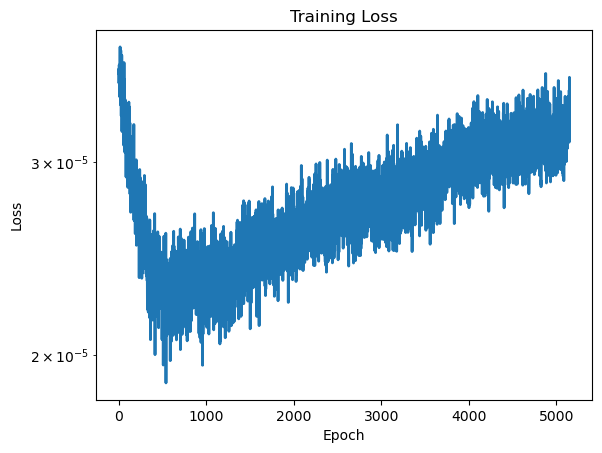

In [7]:


# ---- Live plot setup ----
fig, ax = plt.subplots()
losses = []
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_title("Training Loss")

display(fig)

plot_every = 50  # update frequency (important for speed)

for epoch in range(num_epochs):

    # ---- Sample directly on the coarse mesh ----
    coarse_points = sample_on_coarsemesh(
        coarse_mesh,
        num_samples,
        device="mps",
    ).unsqueeze(0)

    optimizer.zero_grad()

    new_points = disp_modifier_general(
        coarse_points,
        model=disp_mlp
    )

    loss = sdf(
        new_points,
        sdf_id,
        squared=True,
        model=DEEPSDF_MODEL,
        transition_width=sdf_transition_width
    ).mean()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(disp_mlp.parameters(), max_norm=1.0)
    optimizer.step()

    # ---- Logging ----
    loss_val = loss.item()
    losses.append(loss_val)

    if epoch == 0:
        with torch.no_grad():
            baseline_loss = sdf(
                coarse_points,
                sdf_id,
                squared=True,
                model=DEEPSDF_MODEL
            ).mean()
        print(f"Epoch {epoch}: baseline loss = {baseline_loss.item():.10f}")

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss = {loss_val:.10f}")

    # ---- Fast live update (no pause) ----
    if epoch % plot_every == 0:
        line.set_data(range(len(losses)), losses)
        ax.relim()
        ax.autoscale_view()
        clear_output(wait=True)
        display(fig)


In [ ]:
coarse_points.shape

In [ ]:
coarse_patches_id

In [ ]:
tm_mesh = trimesh.load('data/surfaces/'+coarse_patches_id+'.obj')

In [ ]:
import open3d as o3d
import numpy as np
import torch




# ----------------------------
# Load mesh
# ----------------------------
tm_mesh.export('data/surfaces/coarse.obj')
mesh = o3d.io.read_triangle_mesh("data/surfaces/coarse.obj")
mesh.compute_vertex_normals()

# ----------------------------
# Flat subdivision (NO smoothing)
# ----------------------------
# This refines triangles but preserves planarity
mesh_sub = mesh.subdivide_midpoint(number_of_iterations=3)
mesh_sub.compute_vertex_normals()


# ----------------------------
# Apply displacement
# ----------------------------
verts = np.asarray(mesh_sub.vertices)
verts_t = torch.from_numpy(verts).float()

with torch.no_grad():
    displaced = disp_modifier_general(
        verts_t.to('mps'),
        model=disp_mlp,
    )

mesh_disp = o3d.geometry.TriangleMesh()
mesh_disp.vertices = o3d.utility.Vector3dVector(displaced.cpu().numpy())
mesh_disp.triangles = mesh_sub.triangles
mesh_disp.compute_vertex_normals()

# ----------------------------
# Visualisation
# ----------------------------
mesh_sub.paint_uniform_color([0.7, 0.7, 0.7])
mesh_disp.paint_uniform_color([1.0, 0.3, 0.3])

# Offset so both are visible


o3d.visualization.draw_geometries([
    mesh_sub
])


o3d.visualization.draw_geometries([
    mesh_disp
])


'''
o3d.io.write_triangle_mesh(
    'results/urchin/urchin500_disp.obj',
    mesh_disp,
    write_triangle_uvs=False,
    write_vertex_normals=True,
)

o3d.io.write_triangle_mesh(
    'results/urchin/urchin500_sub.obj',
    mesh_sub,
    write_triangle_uvs=False,
    write_vertex_normals=True,
)
'''

In [ ]:

#torch.save(disp_mlp.state_dict(), "results/urchin/bob500_modifier_mlp_weights.pth")

In [ ]:
import torch

import torch

def compute_deformed_normals(coarse_points, disp_fn):
    """
    Compute normals of the deformed mesh by autograd,
    using derivative of output points w.r.t input points.

    coarse_points : (N, 3) float32 tensor, requires_grad=False
    disp_fn       : function mapping points -> deformed points (N,3)
    """

    # Ensure gradients
    coarse_points = coarse_points.detach().clone().requires_grad_(True)

    # Deform points
    new_points = disp_fn(coarse_points)  # (N,3)

    N = new_points.shape[0]

    # Initialize normals tensor
    normals = torch.zeros_like(new_points)

    # Compute Jacobian row-by-row using vmap approach
    # For each point i, compute 3x3 Jacobian
    for i in range(N):
        J = torch.zeros((3, 3), device=coarse_points.device)
        for j in range(3):
            # new_points[i, j] is scalar, grad_outputs must also be scalar
            grad = torch.autograd.grad(
                outputs=new_points[i, j],
                inputs=coarse_points,
                grad_outputs=None,        # None works for scalar
                retain_graph=True,
                create_graph=False,
                only_inputs=True
            )[0][i]  # pick only row i
            J[j] = grad
        # Normal is cross of first two Jacobian rows
        n = torch.linalg.cross(J[0], J[1])
        normals[i] = n / (n.norm() + 1e-8)

    return normals



import open3d as o3d
import numpy as np

def show_normals_as_colors(mesh, normals):
    """
    mesh    : open3d.geometry.TriangleMesh
    normals : (N, 3) torch or numpy array
    """

    # Convert to numpy
    if hasattr(normals, "detach"):
        normals = normals.detach().cpu().numpy()

    # Remove batch dimension if present
    if normals.ndim == 3:
        normals = normals.squeeze(0)

    # Sanity check
    V = np.asarray(mesh.vertices)
    assert normals.shape == V.shape, (
        f"Normals shape {normals.shape} does not match vertices {V.shape}"
    )

    # Map [-1, 1] → [0, 1]
    colors = 0.5 * (normals + 1.0)
    colors = np.clip(colors, 0.0, 1.0)

    # Open3D REQUIREMENTS
    colors = np.ascontiguousarray(colors, dtype=np.float64)

    # Assign
    mesh.vertex_colors = o3d.utility.Vector3dVector(colors)

    o3d.visualization.draw_geometries(
        [mesh],
        mesh_show_back_face=True
    )


verts = torch.from_numpy(np.array(mesh_sub.vertices)).float().to(device)

normals = compute_deformed_normals(
    verts,
    disp_fn=lambda x: disp_modifier_general(x, disp_mlp)
)

show_normals_as_colors(mesh_disp, normals)
